In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()
x_train.shape

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [3]:
x_test.shape

(10000, 32, 32, 3)

In [22]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [23]:
clases=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [27]:
def plot_sample(x,y,index):
 plt.figure(figsize=(15,2))
 plt.imshow(x[index])
 plt.xlabel(clases[y[index]])

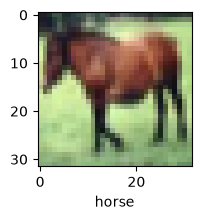

In [28]:
plot_sample(x_train,y_train,7)

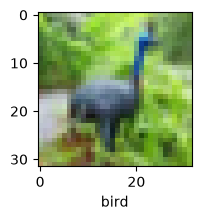

In [29]:
plot_sample(x_train,y_train,6)

In [32]:
x_train=x_train/255
x_test=x_test/255

In [34]:
#first do artificial neuron network
ann=models.Sequential([
  layers.Flatten(input_shape=(32,32,3)),
  layers.Dense(3000,activation='relu'),
  layers.Dense(1000,activation='relu'),
  layers.Dense(10,activation='sigmoid')
])
ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
            )
ann.fit(x_train,y_train,epochs=5)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.3572 - loss: 1.8144
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.4260 - loss: 1.6234
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.4587 - loss: 1.5404
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 46ms/step - accuracy: 0.4787 - loss: 1.4812
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.4949 - loss: 1.4323


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred=ann.predict(x_test)
y_pred_classes=[np.argmax(element) for element in y_pred]
print("classification report: ",classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
classification report:                precision    recall  f1-score   support

           0       0.59      0.46      0.51      1000
           1       0.69      0.36      0.47      1000
           2       0.47      0.07      0.13      1000
           3       0.44      0.15      0.23      1000
           4       0.39      0.40      0.40      1000
           5       0.49      0.22      0.30      1000
           6       0.60      0.40      0.48      1000
           7       0.23      0.88      0.36      1000
           8       0.77      0.30      0.43      1000
           9       0.39      0.70      0.50      1000

    accuracy                           0.39     10000
   macro avg       0.51      0.39      0.38     10000
weighted avg       0.51      0.39      0.38     10000



In [36]:
cnn=models.Sequential([

  #cnn layers
  layers.Conv2D(filters=32,activation='relu',kernel_size=(3,3),input_shape=(32,32,3)),
  layers.MaxPooling2D((2,2)),

  layers.Conv2D(filters=64,activation='relu',kernel_size=(3,3)),
  layers.MaxPooling2D((2,2)),
  #dense network
  layers.Flatten(),
  layers.Dense(64,activation='relu'),
  layers.Dense(10,activation='softmax')
])

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [38]:
cnn.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.4689 - loss: 1.4745
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6064 - loss: 1.1213
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6613 - loss: 0.9821
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6889 - loss: 0.8969
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7134 - loss: 0.8272
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7322 - loss: 0.7685
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7533 - loss: 0.7174
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.7654 - loss: 0.6693
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7820 - loss: 0.6251
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7933 - loss: 0.5905


In [39]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7108 - loss: 0.8804


[0.8803679943084717, 0.7107999920845032]

In [44]:
y_test=y_test.reshape(-1,)
y_test[:5]


array([3, 8, 8, 0, 6], dtype=uint8)

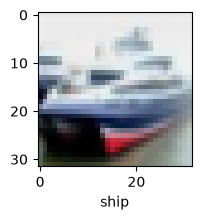

In [45]:
plot_sample(x_test,y_test,1)

In [46]:
y_pred=cnn.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[8.2012052e-03, 4.2619841e-04, 6.9755265e-03, 9.5440805e-01,
        4.4624278e-05, 2.1276684e-02, 4.2195455e-03, 2.8870858e-03,
        1.2967754e-03, 2.6432236e-04],
       [9.1538681e-03, 9.0074696e-02, 2.3668637e-05, 3.3007627e-06,
        1.8813629e-05, 1.1693335e-06, 5.6078915e-07, 2.4900768e-07,
        8.9556187e-01, 5.1617851e-03],
       [1.3607411e-01, 1.3705751e-01, 1.1251468e-02, 2.5284143e-02,
        1.2563291e-03, 8.5962485e-05, 1.8126999e-04, 6.9925707e-04,
        6.5446985e-01, 3.3640161e-02],
       [9.3560737e-01, 2.1323299e-03, 1.6518528e-02, 2.5746049e-03,
        5.4347585e-04, 7.2634512e-06, 4.9492228e-05, 2.2774926e-05,
        4.1489437e-02, 1.0547718e-03],
       [2.5612014e-06, 1.0268858e-05, 6.7426845e-02, 7.0847578e-02,
        1.9418864e-01, 7.2822394e-04, 6.6559637e-01, 2.3675136e-06,
        1.1861956e-03, 1.0958416e-05]], dtype=float32)

In [49]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [50]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

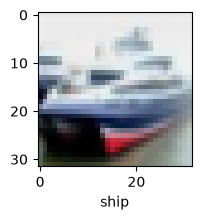

In [51]:
plot_sample(x_test,y_test,1)

In [52]:
clases[y_classes[1]]

'ship'

In [53]:
print("classification report", classification_report(y_test,y_classes))

classification report               precision    recall  f1-score   support

           0       0.74      0.73      0.74      1000
           1       0.83      0.83      0.83      1000
           2       0.61      0.61      0.61      1000
           3       0.50      0.57      0.53      1000
           4       0.66      0.67      0.66      1000
           5       0.67      0.59      0.63      1000
           6       0.83      0.73      0.78      1000
           7       0.73      0.77      0.75      1000
           8       0.81      0.81      0.81      1000
           9       0.76      0.81      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000

